# US Airlines Tweets

### System setup

In [118]:
# Import package
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

## 1. Data understanding - Fleur

In [2]:
# Load data
data = pd.read_csv("Data/Tweets.csv")

### 1.1 Basic understanding

In [3]:
data.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [34]:
# Show the classes of the features
print("Unique sentiment classes: ", data["airline_sentiment"].unique(), "\n")
print("Classes for negative reason: ", data["negativereason"].unique(), "\n")
print("The airlines: ", data["airline"].unique(), "\n")
print("Sentiment classes for gold...?: ", data["airline_sentiment_gold"].unique(), "\n")
print("Classes gold for negative reason: ", data["negativereason_gold"].unique(), "\n")
print("Classes gold for negative reason: ", data["tweet_location"].unique(), "\n")

Unique sentiment classes:  <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str 

Classes for negative reason:  <StringArray>
[                          nan,                  'Bad Flight',
                  'Can't Tell',                 'Late Flight',
      'Customer Service Issue',     'Flight Booking Problems',
                'Lost Luggage', 'Flight Attendant Complaints',
            'Cancelled Flight',             'Damaged Luggage',
                   'longlines']
Length: 11, dtype: str 

The airlines:  <StringArray>
['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways', 'American']
Length: 6, dtype: str 

Sentiment classes for gold...?:  <StringArray>
[nan, 'negative', 'neutral', 'positive']
Length: 4, dtype: str 

Classes gold for negative reason:  <StringArray>
[                                       nan,
 'Late Flight\nFlight Attendant Complaints',
                'Late Flight\nLost Luggage',
                              'Late Flight',
            

In [47]:
print("Shape of the data: ",data.shape, "\n") # shape of the data
print("Columns in the data: \n", data.columns, "\n") # Columnnames
print("Types of the features: \n", data.dtypes) # Data types of the features

Shape of the data:  (14640, 15) 

Columns in the data: 
 Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str') 

Types of the features: 
 tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                

In [53]:
# Describe the numerical features
data.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


### 1.2 Data Quality

In [54]:
# missing values
data.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [66]:
# Duplicates
print("Amount of duplicates in the data:", data.duplicated().sum(), "\n") # 36 duplicates
data[data.duplicated()] # show rows that are duplicates

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
12040,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito
12059,570305051819941889,neutral,1.0,NaN,NaN,American,NaN,Chandrafaythe,NaN,0,@AmericanAir my flight got Cancelled Flightled...,NaN,2015-02-24 11:31:34 -0800,NaN,Quito
12063,570303383782989824,neutral,1.0,NaN,NaN,American,NaN,trentgillaspie,NaN,0,.@AmericanAir just disappointed with the Fligh...,NaN,2015-02-24 11:24:57 -0800,"Austin, but often Denver",Mountain Time (US & Canada)
12066,570301929580048385,neutral,1.0,NaN,NaN,American,NaN,FinEdChat,NaN,0,@AmericanAir I did,NaN,2015-02-24 11:19:10 -0800,"Cincinnati, Ohio",Atlantic Time (Canada)
12068,570301395141836801,negative,1.0,Late Flight,1.0,American,NaN,JoBarredaV,NaN,1,@AmericanAir r u serious?? 304min #delay with ...,NaN,2015-02-24 11:17:02 -0800,Mexico City,Central Time (US & Canada)
12069,570300915418320897,negative,1.0,Cancelled Flight,1.0,American,NaN,LancasterPattie,NaN,0,@AmericanAir You are jumping the gun and Cance...,NaN,2015-02-24 11:15:08 -0800,NaN,NaN
12074,570299252141903873,positive,1.0,NaN,NaN,American,NaN,Mtts28,NaN,0,@AmericanAir This is exactly why ill be flying...,NaN,2015-02-24 11:08:32 -0800,Virginia,Eastern Time (US & Canada)
12075,570298770136674304,negative,1.0,Customer Service Issue,1.0,American,NaN,law_econ,NaN,0,@AmericanAir This doesn't address my issue. I ...,NaN,2015-02-24 11:06:37 -0800,"Newport Beach, CA",Central Time (US & Canada)
12078,570298644475346945,negative,1.0,Customer Service Issue,1.0,American,NaN,denismishin,NaN,0,@AmericanAir submitted a case to AA customer r...,NaN,2015-02-24 11:06:07 -0800,"Bellevue, WA",Eastern Time (US & Canada)
12079,570298371140939776,negative,1.0,Late Flight,1.0,American,NaN,djjohnpayne,NaN,0,@AmericanAir if by near the gate you mean sitt...,"[0.0, 0.0]",2015-02-24 11:05:01 -0800,"Las Vegas, NV",Pacific Time (US & Canada)


In [64]:
data[data["tweet_id"] == 570308309682675712] # show one of the duplicates

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
11879,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito
12040,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito


In [68]:
# Show some random samples to asses quality
data["text"].sample(10, random_state=8)
# see some hashtags, links, abbreviations

6046     @SouthwestAir aww thanks!! Other than that, lo...
10963    @USAirways @AmericanAir I'm in the #finalstret...
758      @united we just flew with United from AUS (Aus...
12064                                  @AmericanAir thanks
12923    @AmericanAir I still can't get through to chan...
12061    @AmericanAir your planes made me miss 2 connec...
4479     @SouthwestAir I "heart" Southwest but those co...
4933     @SouthwestAir Thanks. 436. Only a minor delay ...
5922     @SouthwestAir thanks for your attention, I've ...
6022     @SouthwestAir guess where Ashley is. She's doi...
Name: text, dtype: str

### 1.3 Exploratory Data Analysis

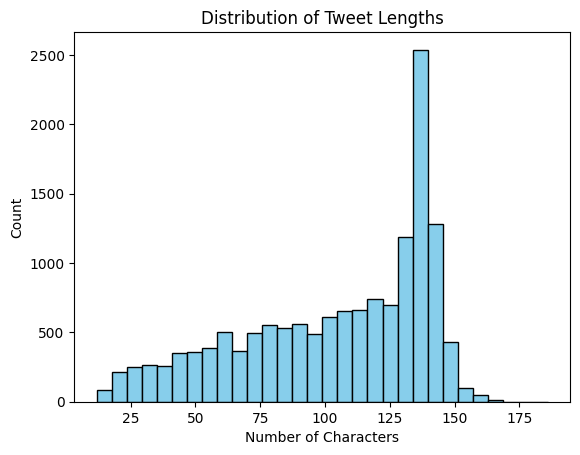

In [115]:
# Length of the tweets in characters
text_length = data["text"].str.len()

# Create the histogram
plt.hist(text_length, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count')

# Save
plt.savefig('plots/text_length_histogram.png')

In [92]:
# Just an example to calculate the number of characters
t = data["text"][0]
print(t)
print(len(t))


@VirginAmerica What @dhepburn said.
35


In [110]:
# Most frequent words
# all tweets in one large string, lowercase everything, and split into words
all_words = ' '.join(data['text']).lower().split()
# Get the frequency of each word
word_freq = Counter(all_words)
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']) # to dataframe
word_freq_df.sort_values(by="Frequency", ascending=False)

,Word,Frequency
8,to,8590
9,the,6034
12,i,5351
37,a,4461
48,for,3964
...,...,...
26831,@jlhalldc,1
26830,"play,",1
26829,answers!,1
26828,3.30pm,1


In [111]:
# Airline balance
airline_counts= data["airline"].value_counts()
airline_counts


airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

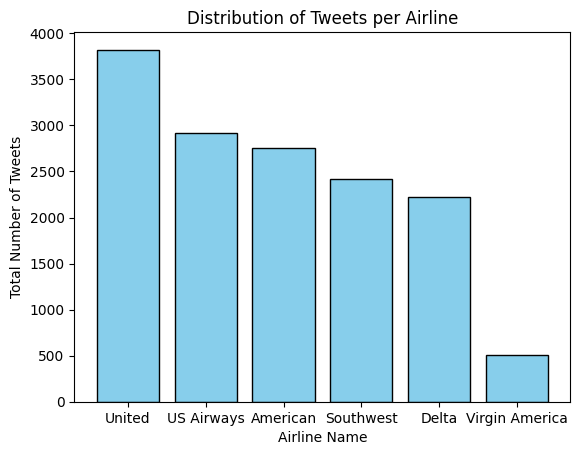

In [116]:
# Plot Airline balance
plt.bar(airline_counts.index, airline_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Tweets per Airline')
plt.xlabel('Airline Name')
plt.ylabel('Total Number of Tweets')

# Save
plt.savefig('airline_class_balance.png')

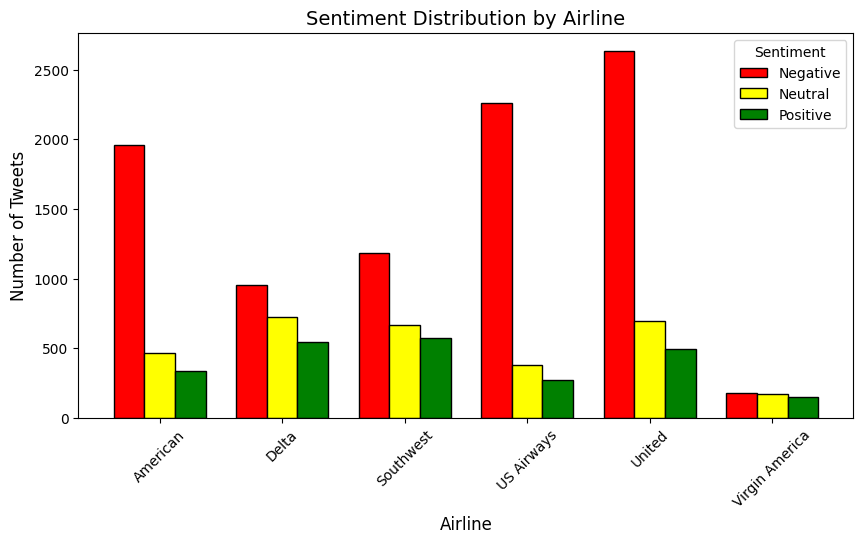

In [129]:
# Class balance per airline
# Group airline with sentiment
sentiment_data = data.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)

# Figure settings
plt.figure(figsize=(10, 5))
airlines = sentiment_data.index
x = np.arange(len(airlines))  # The label locations
width = 0.25

# Plot sentiment group with colors
plt.bar(x - width, sentiment_data['negative'], width, label='Negative', color='red', edgecolor='black')
plt.bar(x, sentiment_data['neutral'], width, label='Neutral', color='yellow', edgecolor='black')
plt.bar(x + width, sentiment_data['positive'], width, label='Positive', color='green', edgecolor='black')

# Figure Layout
plt.title('Sentiment Distribution by Airline', fontsize=14)
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(x, airlines, rotation=45) # Set airline names as x-axis labels
plt.legend(title='Sentiment')

# Save
plt.savefig('sentiment_per_airline.png')

## 2. Data preparation - Coen

tokenization, lowercasing, handling
punctuation, and potentially removing stop words (whenever is deemed necessary and
appropriate). Students should also consider how to handle unknown words (i.e., OOV –
Out of Vocabulary) and how to manage variable-length sequences.

In [67]:
# Delete duplicates

## 3. Modelling

• A baseline model using classical NLP techniques (e.g., TF-IDF + Logistic
Regression or Naive Bayes)

• A neural model such as an LSTM, CNN for text classification, or a Transformer-
based model like BERT.

## 4. Evaluation

The models must be evaluated using metrics such as accuracy, precision, recall, and F1-
score. Students should also include a confusion matrix and perform a qualitative analysis
of misclassified examples.